## Basic Operations for Image Processing

#### Basic Array Operations

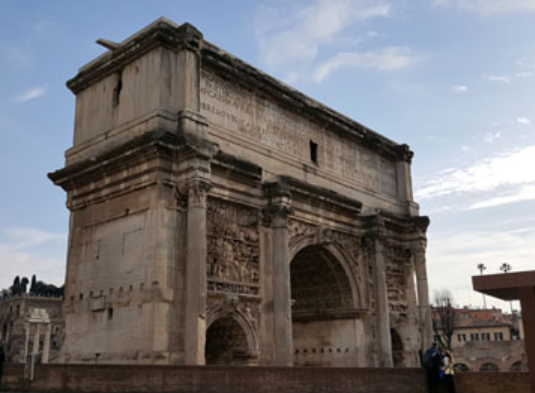

In [ ]:
import numpy as np
import cv2

image = cv2.imread("images/flip_test.jpg", cv2.IMREAD_COLOR)

# x축 기준 상하 뒤집기
x_axis = image[::-1,:, :]
# x_axis = np.flip(image, axis=0)
# x_axis = cv2.flip(image, 0)                 

# y축 기준 좌우 뒤집기
y_axis = image[:, ::-1, :]
# y_axis = np.flip(image, axis=1)
# y_axis = cv2.flip(image, 1)

# x and y
xy_axis = image[::-1, ::-1, :]
# xy_axis = cv2.flip(image, -1)

rep_image   = cv2.repeat(image, ny=2, nx=1)       # 반복횟수 (nx, ny)
# cv2 에서는 x, y 축을 쓰기에 주의
trans_image = cv2.transpose(image)          # 행렬 전치

## 각 행렬을 영상으로 표시
titles = ['image', 'x_axis', 'y_axis','xy_axis','rep_image','trans_image']
for title in titles:
    cv2.imshow(title, eval(title))
cv2.waitKey(0)
cv2.destroyAllWindows()

#### Channels

In [ ]:
import numpy as np
import cv2

# numpy array이용해 단일 채널 3개 생성
ch0 = np.zeros((2, 4), np.uint8) + 10
ch1 = np.ones((2, 4), np.uint8) * 20
ch2 = np.zeros((2, 4), np.uint8); ch2[:] = 30
print("[ch0] = \n%s" % ch0)
print("\n[ch1] = \n%s" % ch1)
print("\n[ch2] = \n%s" % ch2)

merge_bgr = cv2.merge((ch0, ch1, ch2))
# merge_bgr = np.stack(list_bgr, axis=2)
print('\nmerge_bgr:', merge_bgr.shape)

split_bgr = cv2.split(merge_bgr)
print('\nsplit_bgr:', np.array(split_bgr).shape)
# 3,2,4 인 이유
# split_bgr[0] 로 쉽게 빼오기 위해서 임
# merge_bgr[:,:,0] 과 같음


[ch0] = 
[[10 10 10 10]
 [10 10 10 10]]

[ch1] = 
[[20 20 20 20]
 [20 20 20 20]]

[ch2] = 
[[30 30 30 30]
 [30 30 30 30]]

merge_bgr: (2, 4, 3)

split_bgr: (3, 2, 4)


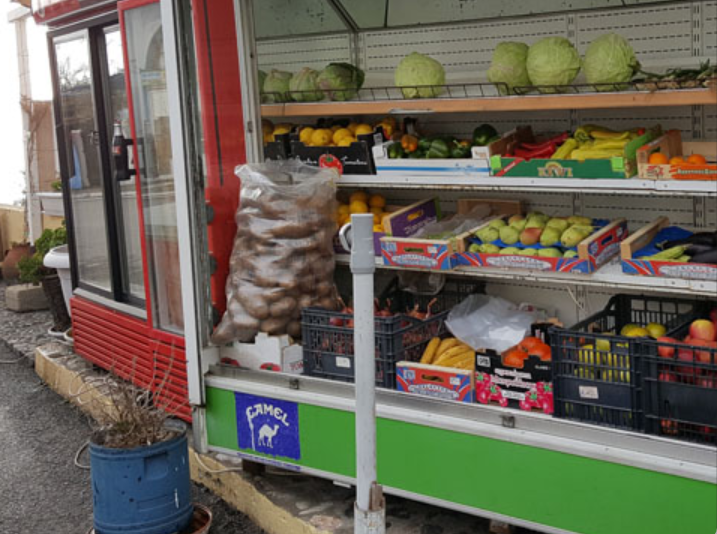

In [ ]:
import cv2

image = cv2.imread( "images/color.jpg", cv2.IMREAD_COLOR)   # 영상 읽기
if image is None: raise Exception("영상 파일 읽기 오류 발생")  # 예외 처리
if image.ndim != 3: raise Exception("컬러 영상 아님")
    
bgr = cv2.split(image)                      # 채널 분리: 컬러영상--> 3채널 분리
# blue, green, red = cv2.split(image)

print("bgr 자료형:",  type(bgr), type(bgr[0]), type(bgr[0][0][0]))
print("bgr 원소개수:", len(bgr))


cv2.imshow("image", image)
cv2.imshow("Blue channel" , bgr[0])         # blue 채널
cv2.imshow("Green channel", bgr[1])         # green 채널
cv2.imshow("Red channel"  , bgr[2])         # red 채널
# cv2.imshow("Blue channel" , image[:,:,0])         	# 넘파이 객체 인덱싱
# cv2.imshow("Green channel", image[:,:,1])
# cv2.imshow("Red channel"  , image[:,:,2])

# 이미지는 2차원으로 나와서 다 흑백임
# 각 채널에서 255라는 의미는 그 채널의 색깔이 많다는 뜻
# 즉 각 채널의 양을 알 수 있음

cv2.waitKey()
cv2.destroyAllWindows()

bgr 자료형: <class 'tuple'> <class 'numpy.ndarray'> <class 'numpy.uint8'>
bgr 원소개수: 3


### OpenCV Mask

#### 1. Mask의 역할
- **`연산 영역 제한:`** 비트 연산 시, 연산을 수행할 `대상 영역`을 지정하는 필터
    - `Mask == 0` (Black): 연산 제외 영역 (결과값 0)
    - `Mask != 0` (Non-zero): 연산 수행 영역 (원본 연산 결과 유지)

#### 2. 데이터 타입 및 조건
- **`Type:`** `CV_8UC1` (unsigned 8-bit integer)
- **`단일 채널 (Grayscale)`** 필수
- **`값의 범위:`** 0 ~ 255

#### 3. 주요 특징
- 0만 아니면(예: 3, 127, 255 등) 모두 동일하게 '연산 실행'
- **`But, 주로 255 사용`**
    - 시각적 확인 용이 (흰색으로 보임)
    - `threshold`, `inRange` 등 주요 함수의 기본 반환값이 255임
    - 이미지 처리의 표준 관습

#### Arithmetic Operations

In [9]:
import numpy as np, cv2

src1 = np.full((3, 6), 10, np.uint8)			# 단일 채널 생성 및 초기화
src2 = np.full((3, 6), 50, np.uint8)
mask = np.zeros(src1.shape, np.uint8)		# 마스크 생성
mask[ :, 3: ] = 255							# 관심 영역을 지정한 후, 255를 할당

added_no_mask = cv2.add(src1, src2)                    # 행렬 덧셈
added_mask = cv2.add(src1, src2, mask=mask)       # 마스크가 Non-Zero(관심 영역)인 픽셀만 덧셈 수행. 나머지는 0

# 행렬 나눗셈 수행
divided_int = cv2.divide(src1, src2)
src1 = src1.astype(np.float32)                  # 형변환 - 소수 부분 보존
src2 = np.float32(src2)
divided_float = cv2.divide(src1, src2)

titles = ['src1', 'src2', 'mask','added_no_mask','added_mask','divided_int', 'divided_float']
for title in titles:
    print(f"[{title}] = \n{eval(title)}\n")

[src1] = 
[[10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10.]]

[src2] = 
[[50. 50. 50. 50. 50. 50.]
 [50. 50. 50. 50. 50. 50.]
 [50. 50. 50. 50. 50. 50.]]

[mask] = 
[[  0   0   0 255 255 255]
 [  0   0   0 255 255 255]
 [  0   0   0 255 255 255]]

[added_no_mask] = 
[[60 60 60 60 60 60]
 [60 60 60 60 60 60]
 [60 60 60 60 60 60]]

[added_mask] = 
[[ 0  0  0 60 60 60]
 [ 0  0  0 60 60 60]
 [ 0  0  0 60 60 60]]

[divided_int] = 
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]

[divided_float] = 
[[0.2 0.2 0.2 0.2 0.2 0.2]
 [0.2 0.2 0.2 0.2 0.2 0.2]
 [0.2 0.2 0.2 0.2 0.2 0.2]]



- **`Fade out / in`**

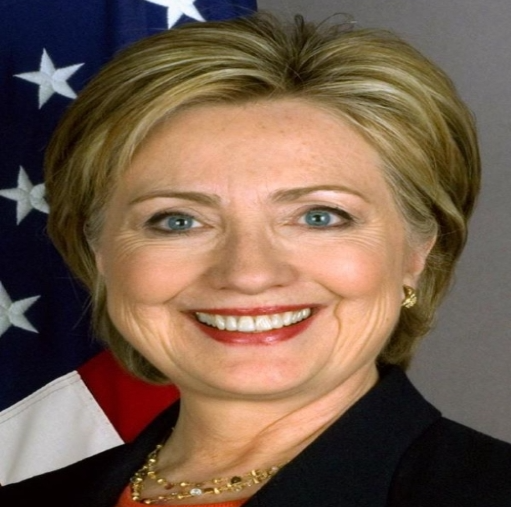 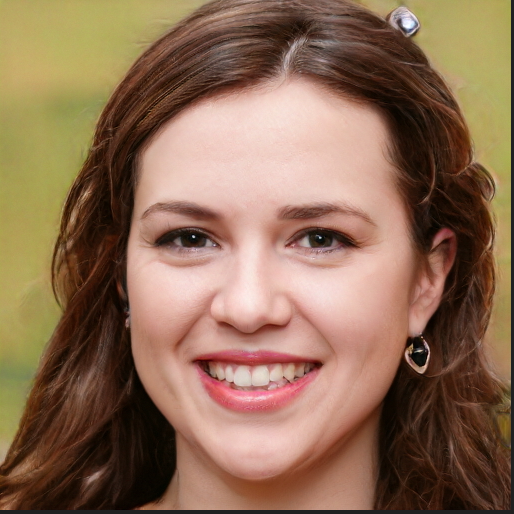

In [2]:
import cv2
import numpy as np

src1= cv2.imread("images/hillary.jpg")
src2= cv2.imread("images/woman.jpg")

src2 = cv2.resize(src2, src1.shape[:2][::-1])   # src2의 크기에 맞게 src1 크기 조절

print(src1.shape, src2.shape)
alpha_lst = np.linspace(0, 1, 100)

fps = 50
t_waiting = int( 1000/fps )
cv2.namedWindow('Merged', cv2.WINDOW_NORMAL)

for alpha in alpha_lst:
    # dst = cv2.addWeighted(src1, alpha, src2, 1-alpha, gamma = 0)
    dst = (src1*alpha + src2*(1-alpha)).astype(np.uint8)
    cv2.imshow('Merged', dst)
    cv2.waitKey(t_waiting)

cv2.waitKey(0)
cv2.destroyAllWindows()

(647, 641, 3) (647, 641, 3)


### Bitwise Operations

#### 비트 반전 연산자(`~`, NOT)는 **2의 보수(2's Complement)** 체계를 따름

$$\color{yellow}\text{2의 보수=1의 보수 + 1}$$


- 1단계: 십진수 5를 2진수로 변환
    - **5** = `0000 0101`

- 2단계: 비트 반전(NOT, `~`) 수행
모든 비트의 `0`을 `1`로, `1`을 `0`으로
    - `~0000 0101` $\rightarrow$ **`1111 1010`**

- 3단계: 결과값 해석 (부호 확인)
    - MSB가 `1`이면 이 숫자를 **음수**로 인식
    - `1111 1010`은 음수
    - 이 값의 십진수 =  `2의 보수`의 절댓값

- 4단계: 2의 보수
    - 1의 보수 (Invert): 1111 1010 $\rightarrow$ 0000 0101 (모든 비트 반전)
    - 1 더하기 (Add 1): 0000 0101 + 1 = 0000 0110
    - 결과: 0000 0110은 십진수로 6이며, 원래 부호가 음수였으므로 최종값은 -6입니다.

#### `핵심 공식`
비트 연산자 `~`의 결과는 항상 다음 공식과 일치합니다.

$$~n = -(n + 1)$$

**예시:**
* $~5 = -(5 + 1) = -6$
* $~10 = -(10 + 1) = -11$
* $~-1 = -(-1 + 1) = 0$

In [7]:
length = 4
a = 5
a_bin = format(a, "b").zfill(length)
b = 7
b_bin = format(b, "b").zfill(length)

res = format(a&b, "b").zfill(length)
print(f"{a}&{b} = {a_bin} & {b_bin} = {res} = {int(res, 2)}")

res = format(a|b, "b").zfill(length)
print(f"{a}|{b} = {a_bin} | {b_bin} = {res} = {int(res, 2)}")

res = format(a^b, "b").zfill(length)
print(f"{a}^{b} = {a_bin} | {b_bin} = {res} = {int(res, 2)}")

res = format(~a, "b").zfill(length)
print(f"~{a} = ~{a_bin} = {res} = {int(res, 2)}")


5&7 = 0101 & 0111 = 0101 = 5
5|7 = 0101 | 0111 = 0111 = 7
5^7 = 0101 | 0111 = 0010 = 2
~5 = ~0101 = -110 = -6


In [8]:
import numpy as np, cv2

np.random.seed(100)
img1 = np.random.randint(low=0, high=6, size=(3, 3), dtype=np.uint8)
img2 = np.random.randint(low=0, high=6, size=(3, 3), dtype=np.uint8)
print("img1:\n", img1)
img_not = cv2.bitwise_not(img1)            	# 행렬 반전
print("~img1:\n", img_not)
print(f"~{img1[0,1]} = -{img1[0,1]}-1 = {-int(img1[0,1])-1}= 256 + {-int(img1[0,1])-1} = {256 -int(img1[0,1])-1} because img1 is uint8")


img1:
 [[0 4 3]
 [0 3 0]
 [3 3 3]]
~img1:
 [[255 251 252]
 [255 252 255]
 [252 252 252]]
~4 = -4-1 = -5= 256 + -5 = 251 because img1 is uint8


In [9]:
print("img1:\n", img1)
print("img2:\n", img2)

img_or = cv2.bitwise_or(img1, img2)     	# 원소 간 논리합
print("img1 or img2:\n", img_or)
img_and = cv2.bitwise_and(img1, img2)    	# 원소 간 논리곱
print("img1 and img2:\n", img_and)
img_xor = cv2.bitwise_xor(img1, img2)    	# 원소 간 배타적 논리합
print("img1 xor img2:\n", img_xor)


img1:
 [[0 4 3]
 [0 3 0]
 [3 3 3]]
img2:
 [[3 1 5]
 [4 0 1]
 [0 3 0]]
img1 or img2:
 [[3 5 7]
 [4 3 1]
 [3 3 3]]
img1 and img2:
 [[0 0 1]
 [0 0 0]
 [0 3 0]]
img1 xor img2:
 [[3 5 6]
 [4 3 1]
 [3 0 3]]


In [3]:
import numpy as np, cv2

img1 = np.zeros((300, 300), np.uint8)     		# 300행, 300열 검은색 영상 생성
img2 = img1.copy()

h, w = img1.shape[:2]
cx,cy  = w//2, h//2
cv2.circle(img1, (cx,cy), 100, 255, -1)      		# 중심에 원 그리기
cv2.rectangle(img2, (0,0, cx, h), 255, -1)

img_or = cv2.bitwise_or(img1, img2)     	# 원소 간 논리합
img_and = cv2.bitwise_and(img1, img2)    	# 원소 간 논리곱
img_xor = cv2.bitwise_xor(img1, img2)    	# 원소 간 배타적 논리합
img_not = cv2.bitwise_not(img1)            	# 행렬 반전

cv2.imshow("img1", img1)
cv2.imshow("img2", img2)
cv2.imshow("bitwise_or", img_or)
cv2.imshow("bitwise_and", img_and)
cv2.imshow("bitwise_xor", img_xor)
cv2.imshow("bitwise_not_img1", img_not)
cv2.waitKey(0)
cv2.destroyAllWindows()

#### Bitwise operations with real colored images

In [ ]:
img1 = cv2.imread("images/hillary.jpg")
img2 = cv2.imread("images/woman.jpg")
img2 = cv2.resize(img2, img1.shape[:2][::-1]) # 이미 shape 맞춰주기

img_or = cv2.bitwise_or(img1, img2)     	# 원소 간 논리합
img_and = cv2.bitwise_and(img1, img2)    	# 원소 간 논리곱
img_xor = cv2.bitwise_xor(img1, img2)    	# 원소 간 배타적 논리합
img_not = cv2.bitwise_not(img1)            	# 행렬 반전

cv2.imshow("img1", img1)
cv2.imshow("img2", img2)
cv2.imshow("bitwise_or", img_or)
cv2.imshow("bitwise_and", img_and)
cv2.imshow("bitwise_xor", img_xor)
cv2.imshow("bitwise_not_img1", img_not)
cv2.waitKey(0)
cv2.destroyAllWindows()

#### - `Masking`
- The pixels that have the corresponding non-zero values in the mask are affected
- The pixels that have zero mask values will be zero.

- **`Selective Processing`**: Masks allow operations to be applied only to specific regions of an image while leaving other parts unchanged.
- **`Region of Interest (ROI) Extraction`**: Helps extract specific objects from an image by masking out unwanted regions.
- **`Combining Images`**: When merging multiple images, masks ensure that only selected portions are blended.

In [12]:
img1 = np.random.randint(low=0, high=6, size=(3, 3), dtype=np.uint8) 
img2 = np.random.randint(low=0, high=6, size=(3, 3), dtype=np.uint8)
print("img1:\n", img1)
print("img2:\n", img2)


# mask = np.array([[255,255,255],[255,255,0],[255,0,0]], dtype=np.uint8)
mask = np.array([[5, 5, 5],[5, 5, 0],[5,0,0]], dtype=np.uint8)
img_or = cv2.bitwise_or(img1, img2, mask=mask)     	# 원소 간 논리합
print(f"mask:\n", mask)
print("img1 or img2 with mask:\n", img_or)

img_and = cv2.bitwise_and(img1, img2, mask=mask)    	# 원소 간 논리곱
print("img1 and img2 with mask:\n", img_and)

img_and = cv2.bitwise_and(img1, img1, mask=mask)    	# 원소 간 논리곱
print("img1 and img1 with mask:\n", img_and)

img1:
 [[2 2 1]
 [5 1 4]
 [0 2 5]]
img2:
 [[2 3 2]
 [1 5 3]
 [3 2 3]]
mask:
 [[5 5 5]
 [5 5 0]
 [5 0 0]]
img1 or img2 with mask:
 [[2 3 3]
 [5 5 0]
 [3 0 0]]
img1 and img2 with mask:
 [[2 2 0]
 [1 1 0]
 [0 0 0]]
img1 and img1 with mask:
 [[2 2 1]
 [5 1 0]
 [0 0 0]]
